# Binary Classification (Logistic Regression)

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import torch
from torch.utils.data import TensorDataset, DataLoader
import torch.nn as nn
from torch.optim import SGD

In [2]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [3]:
torch.__version__

'2.12.0+cpu'

## Prepare Data

In [4]:
df = pd.read_csv("diabetes_dataset.csv")
num_samples, num_features = df.shape
num_features -=1 # remove outcome from features (target)
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,2,138,62,35,0,33.6,0.127,47,1
1,0,84,82,31,125,38.2,0.233,23,0
2,0,145,0,0,0,44.2,0.630,31,1
3,0,135,68,42,250,42.3,0.365,24,1
4,1,139,62,41,480,40.7,0.536,21,0


In [5]:
x = df.drop(["Outcome"], axis=1).values
y = df["Outcome"].values.reshape(-1,1)
x.shape, y.shape

((2000, 8), (2000, 1))

In [6]:
# split train/valid-test 80-20%
x_train, x_test, y_train, y_test = train_test_split(x,y, train_size=0.8, random_state=10)
x_train.shape, y_train.shape, x_test.shape, y_test.shape

((1600, 8), (1600, 1), (400, 8), (400, 1))

In [7]:
# from 1600 samples we split 90% to train data and 10% for validation
x_train, x_valid, y_train, y_valid = train_test_split(x_train, y_train, train_size=0.9)
x_train.shape, y_train.shape, x_valid.shape, y_valid.shape

((1440, 8), (1440, 1), (160, 8), (160, 1))

In [8]:
# scale data to 0-1
x_scaler = StandardScaler()
x_train = x_scaler.fit_transform(x_train)
x_valid = x_scaler.transform(x_valid)
x_test = x_scaler.transform(x_test)

In [9]:
# change dtype from 64 to 32 float
x_train = torch.tensor(x_train, dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.float32)

x_valid = torch.tensor(x_valid, dtype=torch.float32)
y_valid = torch.tensor(y_valid, dtype=torch.float32)

x_test = torch.tensor(x_test, dtype=torch.float32)
y_test = torch.tensor(y_test, dtype=torch.float32)

x_train.shape, y_train.shape, x_valid.shape, y_valid.shape, x_test.shape, y_test.shape

(torch.Size([1440, 8]),
 torch.Size([1440, 1]),
 torch.Size([160, 8]),
 torch.Size([160, 1]),
 torch.Size([400, 8]),
 torch.Size([400, 1]))

In [10]:
# Create dataSet
train_set = TensorDataset(x_train, y_train)
valid_set = TensorDataset(x_valid, y_valid)
test_set = TensorDataset(x_test, y_test)

In [11]:
# Create dataLoader
train_loader = DataLoader(train_set, batch_size=100, shuffle=True)
valid_loader = DataLoader(valid_set, batch_size=80)
test_loader = DataLoader(test_set, batch_size=400)

In [12]:
# get one batch sample from DataLoader for testing model and etc...
x_batch, y_batch = next(iter(train_loader))
x_batch.shape, y_batch.shape

(torch.Size([100, 8]), torch.Size([100, 1]))

In [13]:
# check the len DataLoader as batch items
print(f"DataSet: {len(train_set)}, Batch Count: {len(train_loader)}")  # 14*100 + 40 in last batch

DataSet: 1440, Batch Count: 15


## Prepare Model

In [14]:
# 1. Configuration for reproducibility
torch.manual_seed(42)

# 2. Define the Logistic Regression Model
class LogisticRegressionModel(nn.Module):
    def __init__(self, input_dim: int, output_dim: int):
        super(LogisticRegressionModel, self).__init__()
        # Linear layer
        self.linear = nn.Linear(input_dim, output_dim)
        # Sigmoid
        self.sigmoid = nn.Sigmoid()

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        y = self.linear(x)
        return self.sigmoid(y)

In [15]:
# Test model with sample data  x_batch, y_batch
model = LogisticRegressionModel(num_features, 1)
y_hat = model(x_batch)
y_hat.shape

torch.Size([100, 1])

In [16]:
# Calc loss  (for logistic we need to use binary cross entopy loss)
loss_fn = nn.BCELoss()
loss_fn(y_hat, y_batch)

tensor(0.6969, grad_fn=<BinaryCrossEntropyBackward0>)

In [17]:
# Setup Optimizer
optimizer = SGD(model.parameters(), lr=0.1, momentum=0.9)

In [18]:
# Setup Train epoch
n_epoch = 15
loss_train_hist, loss_valid_hist = [], []
acc_train_hist, acc_valid_hist = [], []

In [19]:
# Train Data
for epoch in range(n_epoch):
    mean_loss_train, mean_loss_valid = 0,0
    mean_acc_train, mean_acc_valid = 0,0

    for x_batch, y_batch in train_loader:

        # Model
        y_hat = model(x_batch)

        # Loss
        loss = loss_fn(y_hat, y_batch)

        loss.backward()
        optimizer.step()
        optimizer.zero_grad()

        mean_loss_train += loss.item() * len(x_batch)
        mean_acc_train += torch.sum(y_hat.round() == y_batch).item()
    
    mean_loss_train = mean_loss_train / len(train_set)
    mean_acc_train = mean_acc_train / len(train_set)
    
    loss_train_hist.append(mean_loss_train)
    acc_train_hist.append(mean_acc_train)


    with torch.no_grad():
        for x_batch, y_batch in valid_loader:
          y_hat = model(x_batch)
          loss = loss_fn(y_hat, y_batch)
          mean_loss_valid += loss.item() * len(x_batch)
          mean_acc_valid += torch.sum(y_hat.round() == y_batch).item()
    
    mean_loss_valid = mean_loss_valid / len(valid_set)
    mean_acc_valid = mean_acc_valid / len(valid_set)
    
    loss_valid_hist.append(mean_loss_valid)
    acc_valid_hist.append(mean_acc_valid)
    
    print(
    f"Epoch: {epoch}   "
    f"LossTrain: {mean_loss_train:.2}   "
    f"AccTrain: {mean_acc_train:.2}   "
    f"LossValid: {mean_loss_valid:.2}   "
    f"AccValid: {mean_acc_valid:.2}"
    )
    

Epoch: 0   LossTrain: 0.58   AccTrain: 0.71   LossValid: 0.49   AccValid: 0.76
Epoch: 1   LossTrain: 0.5   AccTrain: 0.76   LossValid: 0.52   AccValid: 0.76
Epoch: 2   LossTrain: 0.5   AccTrain: 0.77   LossValid: 0.49   AccValid: 0.76
Epoch: 3   LossTrain: 0.5   AccTrain: 0.77   LossValid: 0.49   AccValid: 0.77
Epoch: 4   LossTrain: 0.49   AccTrain: 0.77   LossValid: 0.5   AccValid: 0.77
Epoch: 5   LossTrain: 0.49   AccTrain: 0.77   LossValid: 0.5   AccValid: 0.76
Epoch: 6   LossTrain: 0.49   AccTrain: 0.77   LossValid: 0.49   AccValid: 0.77
Epoch: 7   LossTrain: 0.49   AccTrain: 0.76   LossValid: 0.49   AccValid: 0.77
Epoch: 8   LossTrain: 0.49   AccTrain: 0.76   LossValid: 0.5   AccValid: 0.77
Epoch: 9   LossTrain: 0.49   AccTrain: 0.77   LossValid: 0.5   AccValid: 0.77
Epoch: 10   LossTrain: 0.5   AccTrain: 0.77   LossValid: 0.49   AccValid: 0.76
Epoch: 11   LossTrain: 0.49   AccTrain: 0.77   LossValid: 0.49   AccValid: 0.78
Epoch: 12   LossTrain: 0.5   AccTrain: 0.76   LossValid: 0

In [20]:
# total number of correct guess
torch.sum(y_hat.round() == y_batch)

tensor(65)

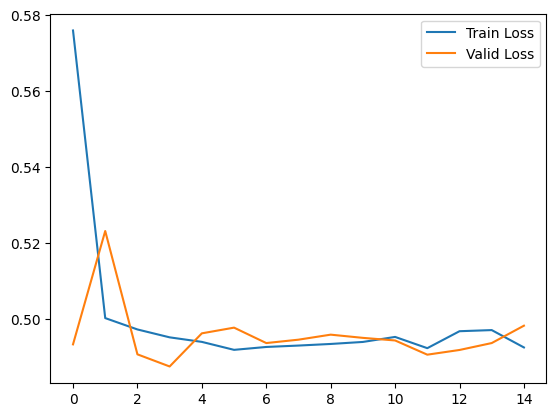

In [21]:
plt.plot(torch.arange(n_epoch), loss_train_hist)
plt.plot(torch.arange(n_epoch), loss_valid_hist)
plt.legend(["Train Loss", "Valid Loss"]);

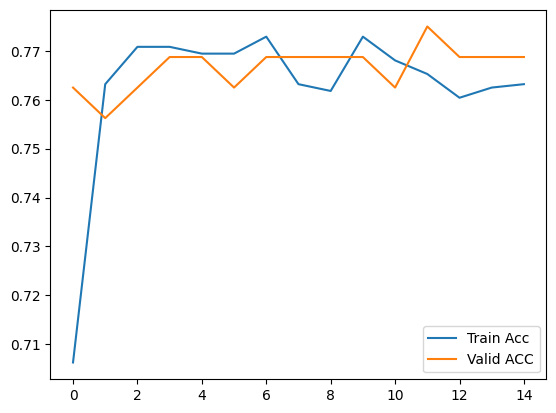

In [22]:
plt.plot(torch.arange(n_epoch), acc_train_hist)
plt.plot(torch.arange(n_epoch), acc_valid_hist)
plt.legend(["Train Acc", "Valid ACC"]);

In [23]:
mean_acc_test = 0

with torch.no_grad():
  for x_batch, y_batch in test_loader:
    y_hat = model(x_batch)
    mean_acc_test += torch.sum(y_hat.round() == y_batch).item()
  mean_acc_test = mean_acc_test / len(test_set)

mean_acc_test

0.8075